# Técnica 1: MLP

In [ ]:
# Importación de librerías
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import time
import pandas as pd
import numpy as np

# Configuración opcional
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

# Cargar dataset
df = pd.read_csv("dataset_elpino.csv", sep=";", encoding="utf-8")

# Ver primeras filas
df.head()

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),Diag 11 Secundario (cod+des),Diag 12 Secundario (cod+des),Diag 13 Secundario (cod+des),Diag 14 Secundario (cod+des),Diag 15 Secundario (cod+des),Diag 16 Secundario (cod+des),Diag 17 Secundario (cod+des),Diag 18 Secundario (cod+des),Diag 19 Secundario (cod+des),Diag 20 Secundario (cod+des),Diag 21 Secundario (cod+des),Diag 22 Secundario (cod+des),Diag 23 Secundario (cod+des),Diag 24 Secundario (cod+des),Diag 25 Secundario (cod+des),Diag 26 Secundario (cod+des),Diag 27 Secundario (cod+des),Diag 28 Secundario (cod+des),Diag 29 Secundario (cod+des),Diag 30 Secundario (cod+des),Diag 31 Secundario (cod+des),Diag 32 Secundario (cod+des),Diag 33 Secundario (cod+des),Diag 34 Secundario (cod+des),Diag 35 Secundario (cod+des),Proced 01 Principal (cod+des),Proced 02 Secundario (cod+des),Proced 03 Secundario (cod+des),Proced 04 Secundario (cod+des),Proced 05 Secundario (cod+des),Proced 06 Secundario (cod+des),Proced 07 Secundario (cod+des),Proced 08 Secundario (cod+des),Proced 09 Secundario (cod+des),Proced 10 Secundario (cod+des),Proced 11 Secundario (cod+des),Proced 12 Secundario (cod+des),Proced 13 Secundario (cod+des),Proced 14 Secundario (cod+des),Proced 15 Secundario (cod+des),Proced 16 Secundario (cod+des),Proced 17 Secundario (cod+des),Proced 18 Secundario (cod+des),Proced 19 Secundario (cod+des),Proced 20 Secundario (cod+des),Proced 21 Secundario (cod+des),Proced 22 Secundario (cod+des),Proced 23 Secundario (cod+des),Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,"U07.1 - COVID-19, virus identificado",Y95 - Afección nosocomial,"N18.5 - Enfermedad renal crónica, estadio 5",E87.1 - Hiposmolaridad e hiponatremia,D64.9 - Anemia de tipo no especificado,"G82.2 - Paraplejía, no especificada","N31.9 - Disfunción neuromuscular de la vejiga,...",I10 - Hipertensión esencial (primaria),K70.4 - Insuficiencia hepática alcohólica,F19.2 - Trastornos mentales y del comportamien...,F10.2 - Trastornos mentales y del comportamien...,"E46 - Desnutrición proteicocalórica, no especi...","G40.9 - Epilepsia, tipo no especificado","L21.9 - Dermatitis seborreica, no especificada",Z93.5 - Cistostomía,Z93.3 - Colostomía,Z99.2 - Dependencia de diálisis renal,Z91.6 - Historia personal de otro trauma físico,-,-,-,-,-,-,-,"86.28 - DESBRIDAMIENTO HERIDA,INFECCION O QUEM...",34.91 - TORACOCENTESIS,88.38 - TOMOGRAFIA AXIAL COMPUTERIZADA OTRA,87.41 - TOMOGRAFIA AXIAL COMPUTERIZADA TORAX,88.75 - ECOGRAFIA APARATO URINARIO,88.01 - TOMOGRAFIA AXIAL COMPUTERIZADA ABDOMEN,88.43 - ARTERIOGRAFIA ARTERIA PULMONAR,88.41 - ARTERIOGRAFIA ARTERIA CEREBRAL,87.44 - RADIOGRAFIA TORAX RUTINARIA,99.29 - INYECCION SUSTANCIA TERAPEUTICA O PROF...,99.19 - INYECCION ANTICOAGULANTE,99.18 - INYECCION ELECTROLITO,99.21 - INYECCION ANTIBIOTICO,99.26 - INYECCION TRANQUILIZANTE,99.23 - INYECCION ESTEROIDE,93.94 - AEROSOLTERAPIA,89.52 - ELECTROCARDIOGRAFIA,90.59 - EXAMEN MICROSCOPICO SANGRE.OTRO,89.65 - GASOMETRIA ARTERIA,39.95 - HEMODIALISIS,39.95 - HEMODIALISIS,99.04 - TRANSFUSION CONCENTRADO HEMATIES,90.39 - EXAMEN MICROSCOPICO ORL.OTRO,99.84 - AISLAMIENTO,88.7

In [ ]:
# Dimensiones del dataset
print("Shape del dataset:", df.shape)

# Nombres de columnas
print("\nColumnas:")
print(df.columns.tolist())

# Tipos de datos
print("\nTipos de datos:")
print(df.dtypes)

# Valores nulos
print("\nValores nulos:")
print(df.isnull().sum())

# Edad promedio hombres vs mujeres
print("Edad promedio por sexo:")
df["Edad en años"].groupby(df["Sexo (Desc)"]).mean()

Shape del dataset: (14561, 68)

Columnas:
['Diag 01 Principal (cod+des)', 'Diag 02 Secundario (cod+des)', 'Diag 03 Secundario (cod+des)', 'Diag 04 Secundario (cod+des)', 'Diag 05 Secundario (cod+des)', 'Diag 06 Secundario (cod+des)', 'Diag 07 Secundario (cod+des)', 'Diag 08 Secundario (cod+des)', 'Diag 09 Secundario (cod+des)', 'Diag 10 Secundario (cod+des)', 'Diag 11 Secundario (cod+des)', 'Diag 12 Secundario (cod+des)', 'Diag 13 Secundario (cod+des)', 'Diag 14 Secundario (cod+des)', 'Diag 15 Secundario (cod+des)', 'Diag 16 Secundario (cod+des)', 'Diag 17 Secundario (cod+des)', 'Diag 18 Secundario (cod+des)', 'Diag 19 Secundario (cod+des)', 'Diag 20 Secundario (cod+des)', 'Diag 21 Secundario (cod+des)', 'Diag 22 Secundario (cod+des)', 'Diag 23 Secundario (cod+des)', 'Diag 24 Secundario (cod+des)', 'Diag 25 Secundario (cod+des)', 'Diag 26 Secundario (cod+des)', 'Diag 27 Secundario (cod+des)', 'Diag 28 Secundario (cod+des)', 'Diag 29 Secundario (cod+des)', 'Diag 30 Secundario (cod+des)'

,Edad en años
Sexo (Desc),
Hombre,43.604976
Mujer,37.278465


In [ ]:
# Número de clases únicas
num_clases = df["GRD"].nunique()
print("Número de clases (GRD):", num_clases)

# Conteo de ejemplos por clase
class_counts = df["GRD"].value_counts()

print("\nTop 10 clases más frecuentes:")
print(class_counts.head(10))

print("\nClases menos frecuentes:")
print(class_counts.tail(10))

Número de clases (GRD): 526

Top 10 clases más frecuentes:
GRD
146101 - PH CESÁREA                                                                       813
146121 - PH PARTO VAGINAL CON PROCED., EXCEPTO ESTERILIZACIÓN Y/O DILATACIÓN Y LEGRADO    639
146131 - PH PARTO VAGINAL                                                                 538
158171 - MH NEONATO, PESO AL NACER >2499 GR SIN PROCEDIMIENTO MAYOR                       389
134161 - MH TRASTORNOS DEL ANTEPARTO                                                      325
071141 - PH COLECISTECTOMÍA LAPAROSCÓPICA                                                 317
044153 - MH INFECCIONES E INFLAMACIONES RESPIRATORIAS W/MCC                               287
061131 - PH PROCEDIMIENTOS SOBRE APÉNDICE                                                 252
041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC                       248
146102 - PH CESÁREA W/CC                                                                  2

In [ ]:
# =========================================
# 1. EXTRAER SOLO CÓDIGO DE GRD
# =========================================
df["GRD_codigo"] = df["GRD"].apply(lambda x: str(x).split(" - ")[0])

# =========================================
# 2. SELECCIONAR TOP 30 CLASES
# =========================================
top_n = 30

top_classes = df["GRD_codigo"].value_counts().head(top_n).index

df = df[df["GRD_codigo"].isin(top_classes)].copy()

print("Nuevo número de clases:", df["GRD_codigo"].nunique())
print("Nuevo tamaño dataset:", df.shape)

# =========================================
# 3. LIMPIAR DIAGNÓSTICOS (dejando solo códigos)
# =========================================
diag_cols = [col for col in df.columns if "Diag" in col]

def limpiar_codigos(row):
    codigos = []
    for col in diag_cols:
        val = str(row[col])
        if val != "-" and val != "nan":
            codigo = val.split(" - ")[0]
            codigos.append(codigo)
    return " ".join(codigos)

df["Diagnosticos"] = df.apply(limpiar_codigos, axis=1)

# =========================================
# 4. LIMPIAR PROCEDIMIENTOS (dejando solo códigos)
# =========================================
proc_cols = [col for col in df.columns if "Proced" in col]

def limpiar_procedimientos(row):
    codigos = []
    for col in proc_cols:
        val = str(row[col])
        if val != "-" and val != "nan":
            codigo = val.split(" - ")[0]
            codigos.append(codigo)
    return " ".join(codigos)

df["Procedimientos"] = df.apply(limpiar_procedimientos, axis=1)

# =========================================
# 5. BINARIZAR SEXO
# =========================================
df["Sexo_binario"] = df["Sexo (Desc)"].map({
    "Hombre": 1,
    "Mujer": 0
})

# =========================================
# 6. PREPARAR VARIABLES FINALES
# =========================================
X_text_diag = df["Diagnosticos"]
X_text_proc = df["Procedimientos"]
X_edad = df["Edad en años"]
X_sexo = df["Sexo_binario"]

y = df["GRD_codigo"]

# =========================================
# 7. COUNT VECTORIZER (DIAGNÓSTICOS)
# =========================================
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_diag = CountVectorizer()
X_diag = vectorizer_diag.fit_transform(X_text_diag)

# =========================================
# 8. COUNT VECTORIZER (PROCEDIMIENTOS)
# =========================================
vectorizer_proc = CountVectorizer()
X_proc = vectorizer_proc.fit_transform(X_text_proc)

# =========================================
# 9. COMBINAR TODO
# =========================================
from scipy.sparse import hstack

X = hstack([X_diag, X_proc])

# Agregar edad y sexo
import numpy as np

X_extra = np.array([X_edad, X_sexo]).T

from scipy.sparse import csr_matrix

X = hstack([X, csr_matrix(X_extra)])

print("Shape final de X:", X.shape)
print("Número de clases:", y.nunique())

Nuevo número de clases: 30
Nuevo tamaño dataset: (7106, 69)
Shape final de X: (7106, 1135)
Número de clases: 30


In [ ]:
# =========================================
# DIVISIÓN TRAIN / TEST (ESTRATIFICADA)
# =========================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,        # 20% para test
    random_state=42,      # Reproducibilidad
    stratify=y            # Mantener proporción de clases
)

# =========================================
# VERIFICACIÓN
# =========================================
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nDistribución clases en TRAIN:")
print(y_train.value_counts(normalize=True).head())

print("\nDistribución clases en TEST:")
print(y_test.value_counts(normalize=True).head())

Train shape: (5684, 1135)
Test shape: (1422, 1135)

Distribución clases en TRAIN:
GRD_codigo
146101    0.114356
146121    0.089901
146131    0.075651
158171    0.054715
134161    0.045742
Name: proportion, dtype: float64

Distribución clases en TEST:
GRD_codigo
146101    0.114627
146121    0.090014
146131    0.075949
158171    0.054852
134161    0.045710
Name: proportion, dtype: float64


In [ ]:
# =========================================
# CODIFICAR ETIQUETAS (GRD)
# =========================================
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

num_classes = len(le.classes_)

In [ ]:
# =========================================
# CONFIGURACIÓN DE REPRODUCIBILIDAD
# =========================================
import os
import random
import numpy as np
import tensorflow as tf

semilla = 42

# Fijar semillas en todas las librerías
os.environ['PYTHONHASHSEED'] = str(semilla)
random.seed(semilla)
np.random.seed(semilla)
tf.random.set_seed(semilla)

# Opcional: Forzar determinismo en operaciones de GPU (útil en Colab)
tf.config.experimental.enable_op_determinism()

In [ ]:
"""
MODELO 1 (CARACTERISTICAS):
Capas ocultas = 1
N° de Perceptrones por capa: 128 (Densa)
"""

# DEFINICIÓN DEL MODELO
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ENTRENAMIENTO DEL MODELO (Con medición de tiempo)
start_train = time.time()

history = model.fit(
    X_train.toarray(),
    y_train_enc,
    epochs=15,
    batch_size=32,
    verbose=1
)

end_train = time.time()

print("\nTiempo de entrenamiento:", end_train - start_train, "segundos")

# PRUEBA DEL MODELO
start_test = time.time()

y_pred_prob = model.predict(X_test.toarray())
y_pred = np.argmax(y_pred_prob, axis=1)

end_test = time.time()

print("Tiempo de test:", end_test - start_test, "segundos")

# MÉTRICAS
accuracy = accuracy_score(y_test_enc, y_pred)

print("\nAccuracy:", accuracy)

print("\nReporte completo:")
print(classification_report(y_test_enc, y_pred))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5832 - loss: 1.8237
Epoch 2/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8228 - loss: 0.6663
Epoch 3/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8788 - loss: 0.4204
Epoch 4/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9071 - loss: 0.3108
Epoch 5/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9243 - loss: 0.2469
Epoch 6/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9395 - loss: 0.2052
Epoch 7/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9460 - loss: 0.1757
Epoch 8/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9518 - loss: 0.1541
Epoch 9/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9574 - loss: 0.1375
Epoch 10/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9616 - loss: 0.1244
Epoch 11/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9655 - loss: 0.1137
Epoch 12/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [ ]:
# =========================================
# 1. CALCULAR CLASS WEIGHTS
# =========================================
from sklearn.utils.class_weight import compute_class_weight

import numpy as np

classes = np.unique(y_train_enc)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_enc
)

class_weights = dict(zip(classes, weights))

print("Class weights:", class_weights)

# =========================================
# 2. DEFINIR MODELO (MISMA ARQUITECTURA)
# =========================================
model_2 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(num_classes, activation='softmax')
])

model_2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================================
# 3. ENTRENAMIENTO (CON CLASS WEIGHT)
# =========================================
import time

start_train = time.time()

history_2 = model_2.fit(
    X_train.toarray(),
    y_train_enc,
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

end_train = time.time()

print("\nTiempo de entrenamiento:", end_train - start_train, "segundos")

# =========================================
# 4. PREDICCIÓN
# =========================================
start_test = time.time()

y_pred_prob_2 = model_2.predict(X_test.toarray())
y_pred_2 = np.argmax(y_pred_prob_2, axis=1)

end_test = time.time()

print("Tiempo de test:", end_test - start_test, "segundos")

# =========================================
# 5. MÉTRICAS
# =========================================
from sklearn.metrics import classification_report, accuracy_score

accuracy_2 = accuracy_score(y_test_enc, y_pred_2)

print("\nAccuracy:", accuracy_2)

print("\nReporte completo:")
print(classification_report(y_test_enc, y_pred_2))


Class weights: {np.int64(0): np.float64(1.9532646048109965), np.int64(1): np.float64(0.9569023569023569), np.int64(2): np.float64(1.8217948717948718), np.int64(3): np.float64(0.823768115942029), np.int64(4): np.float64(1.0353369763205829), np.int64(5): np.float64(1.6333333333333333), np.int64(6): np.float64(1.754320987654321), np.int64(7): np.float64(1.1623721881390594), np.int64(8): np.float64(0.9379537953795379), np.int64(9): np.float64(1.540379403794038), np.int64(10): np.float64(2.2827309236947793), np.int64(11): np.float64(0.7459317585301837), np.int64(12): np.float64(1.839482200647249), np.int64(13): np.float64(2.0594202898550726), np.int64(14): np.float64(1.7707165109034269), np.int64(15): np.float64(1.7382262996941895), np.int64(16): np.float64(1.9943859649122806), np.int64(17): np.float64(1.0467771639042358), np.int64(18): np.float64(1.0644194756554306), np.int64(19): np.float64(1.706906906906907), np.int64(20): np.float64(0.7287179487179487), np.int64(21): np.float64(0.291487

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4870 - loss: 2.1278
Epoch 2/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7882 - loss: 0.7494
Epoch 3/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8663 - loss: 0.4423
Epoch 4/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8994 - loss: 0.3190
Epoch 5/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9170 - loss: 0.2486
Epoch 6/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9298 - loss: 0.2024
Epoch 7/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9407 - loss: 0.1698
Epoch 8/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9483 - loss: 0.1456
Epoch 9/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9536 - loss: 0.1277
Epoch 10/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9581 - loss: 0.1135
Epoch 11/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9613 - loss: 0.1019
Epoch 12/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy

In [ ]:
# =========================================
# 1. DEFINIR MODELO CON DROPOUT
# =========================================
from tensorflow.keras.layers import Dropout

model_3 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================================
# 2. ENTRENAMIENTO (CON CLASS_WEIGHT)
# =========================================
import time

start_train = time.time()

history_3 = model_3.fit(
    X_train.toarray(),
    y_train_enc,
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

end_train = time.time()

print("\nTiempo de entrenamiento:", end_train - start_train, "segundos")

# =========================================
# 3. PREDICCIÓN
# =========================================
start_test = time.time()

y_pred_prob_3 = model_3.predict(X_test.toarray())
y_pred_3 = np.argmax(y_pred_prob_3, axis=1)

end_test = time.time()

print("Tiempo de test:", end_test - start_test, "segundos")

# =========================================
# 4. MÉTRICAS
# =========================================
accuracy_3 = accuracy_score(y_test_enc, y_pred_3)

print("\nAccuracy:", accuracy_3)

print("\nReporte completo:")
print(classification_report(y_test_enc, y_pred_3))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3654 - loss: 2.5072
Epoch 2/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6645 - loss: 1.1237
Epoch 3/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7593 - loss: 0.7001
Epoch 4/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7979 - loss: 0.5290
Epoch 5/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8339 - loss: 0.4215
Epoch 6/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8691 - loss: 0.3458
Epoch 7/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8883 - loss: 0.2891
Epoch 8/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8981 - loss: 0.2590
Epoch 9/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9106 - loss: 0.2285
Epoch 10/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9222 - loss: 0.2035
Epoch 11/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9316 - loss: 0.1892
Epoch 12/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [ ]:
# =========================================
# 10 VARIACIONES DEL MODELO (DROPOUT) CON MÉTRICAS COMPLETAS
# =========================================
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report
import time

# Definimos 10 configuraciones diferentes
variaciones = [
    {"nombre": "Var 1", "capas": [64], "dropout": 0.0, "lr": 0.001},
    {"nombre": "Var 2", "capas": [128], "dropout": 0.1, "lr": 0.001},
    {"nombre": "Var 3", "capas": [256], "dropout": 0.3, "lr": 0.001},
    {"nombre": "Var 4", "capas": [128, 64], "dropout": 0.2, "lr": 0.001},
    {"nombre": "Var 5", "capas": [256, 128], "dropout": 0.4, "lr": 0.001},
    {"nombre": "Var 6", "capas": [64, 32], "dropout": 0.1, "lr": 0.005},
    {"nombre": "Var 7", "capas": [128, 128], "dropout": 0.3, "lr": 0.0005},
    {"nombre": "Var 8", "capas": [256, 128, 64], "dropout": 0.3, "lr": 0.001},
    {"nombre": "Var 9", "capas": [512, 256], "dropout": 0.5, "lr": 0.001},
    {"nombre": "Var 10", "capas": [128], "dropout": 0.2, "lr": 0.01}
]

resultados = []

for var in variaciones:
    print(f"\nEntrenando {var['nombre']} | Capas: {var['capas']} | Dropout: {var['dropout']} | LR: {var['lr']}")

    # 1. Construcción dinámica del modelo
    model_grid = Sequential()
    model_grid.add(Dense(var['capas'][0], activation='relu', input_shape=(X_train.shape[1],)))
    if var['dropout'] > 0:
        model_grid.add(Dropout(var['dropout']))

    for neuronas in var['capas'][1:]:
        model_grid.add(Dense(neuronas, activation='relu'))
        if var['dropout'] > 0:
            model_grid.add(Dropout(var['dropout']))

    model_grid.add(Dense(num_classes, activation='softmax'))

    model_grid.compile(optimizer=Adam(learning_rate=var['lr']),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

    # 2. Entrenar modelo
    model_grid.fit(X_train.toarray(), y_train_enc, epochs=10, batch_size=32, verbose=0, class_weight=class_weights)

    # 3. Predecir
    y_pred_prob_grid = model_grid.predict(X_test.toarray(), verbose=0)
    y_pred_grid = np.argmax(y_pred_prob_grid, axis=1)

    # 4. Extraer TODAS las métricas como diccionario (zero_division=0 para evitar warnings de Colab)
    reporte = classification_report(y_test_enc, y_pred_grid, output_dict=True, zero_division=0)

    # Guardar métricas específicas
    acc = reporte['accuracy']

    macro_prec = reporte['macro avg']['precision']
    macro_rec = reporte['macro avg']['recall']
    macro_f1 = reporte['macro avg']['f1-score']

    weight_prec = reporte['weighted avg']['precision']
    weight_rec = reporte['weighted avg']['recall']
    weight_f1 = reporte['weighted avg']['f1-score']

    # 5. Agregar a la lista de resultados
    resultados.append({
        "Modelo": var['nombre'],
        "Accuracy": round(acc, 4),
        "Macro Prec": round(macro_prec, 4),
        "Macro Recall": round(macro_rec, 4),
        "Macro F1": round(macro_f1, 4),
        "Weighted Prec": round(weight_prec, 4),
        "Weighted Recall": round(weight_rec, 4),
        "Weighted F1": round(weight_f1, 4)
    })
    print(f"-> Listo. Accuracy: {acc:.4f} | Weighted F1: {weight_f1:.4f}")

# =========================================
# MOSTRAR TABLA FINAL DE RESULTADOS
# =========================================
print("\n=== RESUMEN DETALLADO DE LAS 10 VARIACIONES ===")
# Convertir a DataFrame y ordenar por Accuracy de mayor a menor
resumen_df = pd.DataFrame(resultados).sort_values(by="Accuracy", ascending=False)

# Mostrar la tabla en Colab
display(resumen_df)


Entrenando Var 1 | Capas: [64] | Dropout: 0.0 | LR: 0.001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


-> Listo. Accuracy: 0.8875 | Weighted F1: 0.8884

Entrenando Var 2 | Capas: [128] | Dropout: 0.1 | LR: 0.001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


-> Listo. Accuracy: 0.8847 | Weighted F1: 0.8854

Entrenando Var 3 | Capas: [256] | Dropout: 0.3 | LR: 0.001


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


-> Listo. Accuracy: 0.8931 | Weighted F1: 0.8939

Entrenando Var 10 | Capas: [128] | Dropout: 0.2 | LR: 0.01


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


-> Listo. Accuracy: 0.8692 | Weighted F1: 0.8726

=== RESUMEN DETALLADO DE LAS 10 VARIACIONES ===


,Modelo,Accuracy,Macro Prec,Macro Recall,Macro F1,Weighted Prec,Weighted Recall,Weighted F1
4,Var 5,0.8938,0.8875,0.8868,0.8838,0.9018,0.8938,0.8950
8,Var 9,0.8931,0.8850,0.8813,0.8799,0.8996,0.8931,0.8939
2,Var 3,0.8917,0.8828,0.8838,0.8801,0.8981,0.8917,0.8924
3,Var 4,0.8889,0.8851,0.8875,0.8823,0.8983,0.8889,0.8905
0,Var 1,0.8875,0.8784,0.8796,0.8762,0.8938,0.8875,0.8884
7,Var 8,0.8868,0.8844,0.8700,0.8712,0.8947,0.8868,0.8866
1,Var 2,0.8847,0.8750,0.8748,0.8720,0.8906,0.8847,0.8854
9,Var 10,0.8692,0.8617,0.8599,0.8535,0.8859,0.8692,0.8726
5,Var 6,0.8643,0.8629,0.8494,0.8457,0.8861,0.8643,0.8664
6,Var 7,0.8629,0.8535,0.8701,0.8564,0.8786,0.8629,0.8660


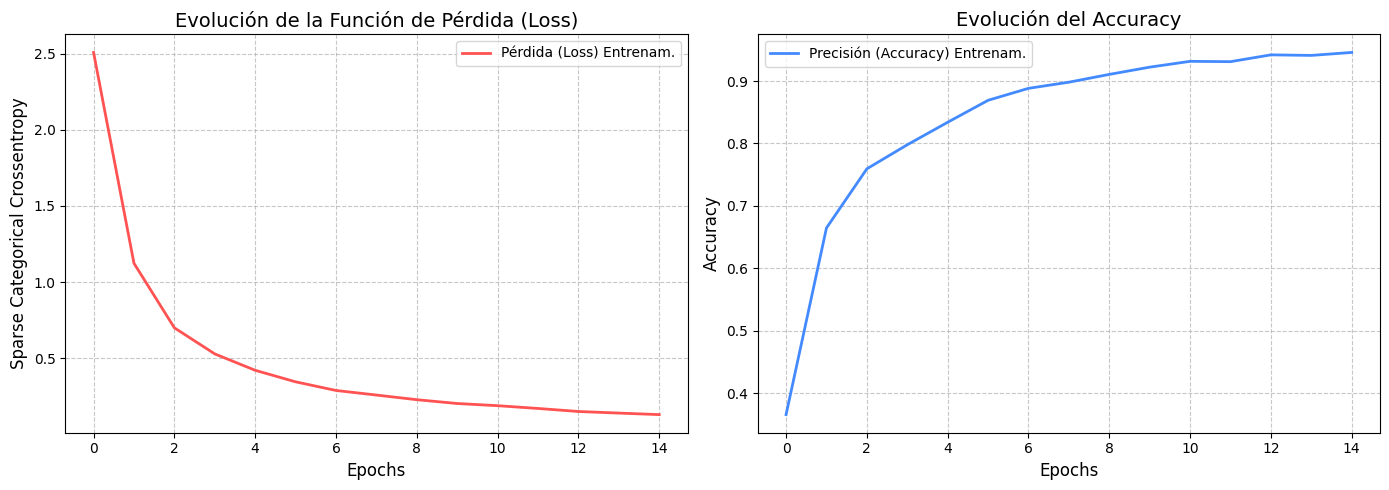

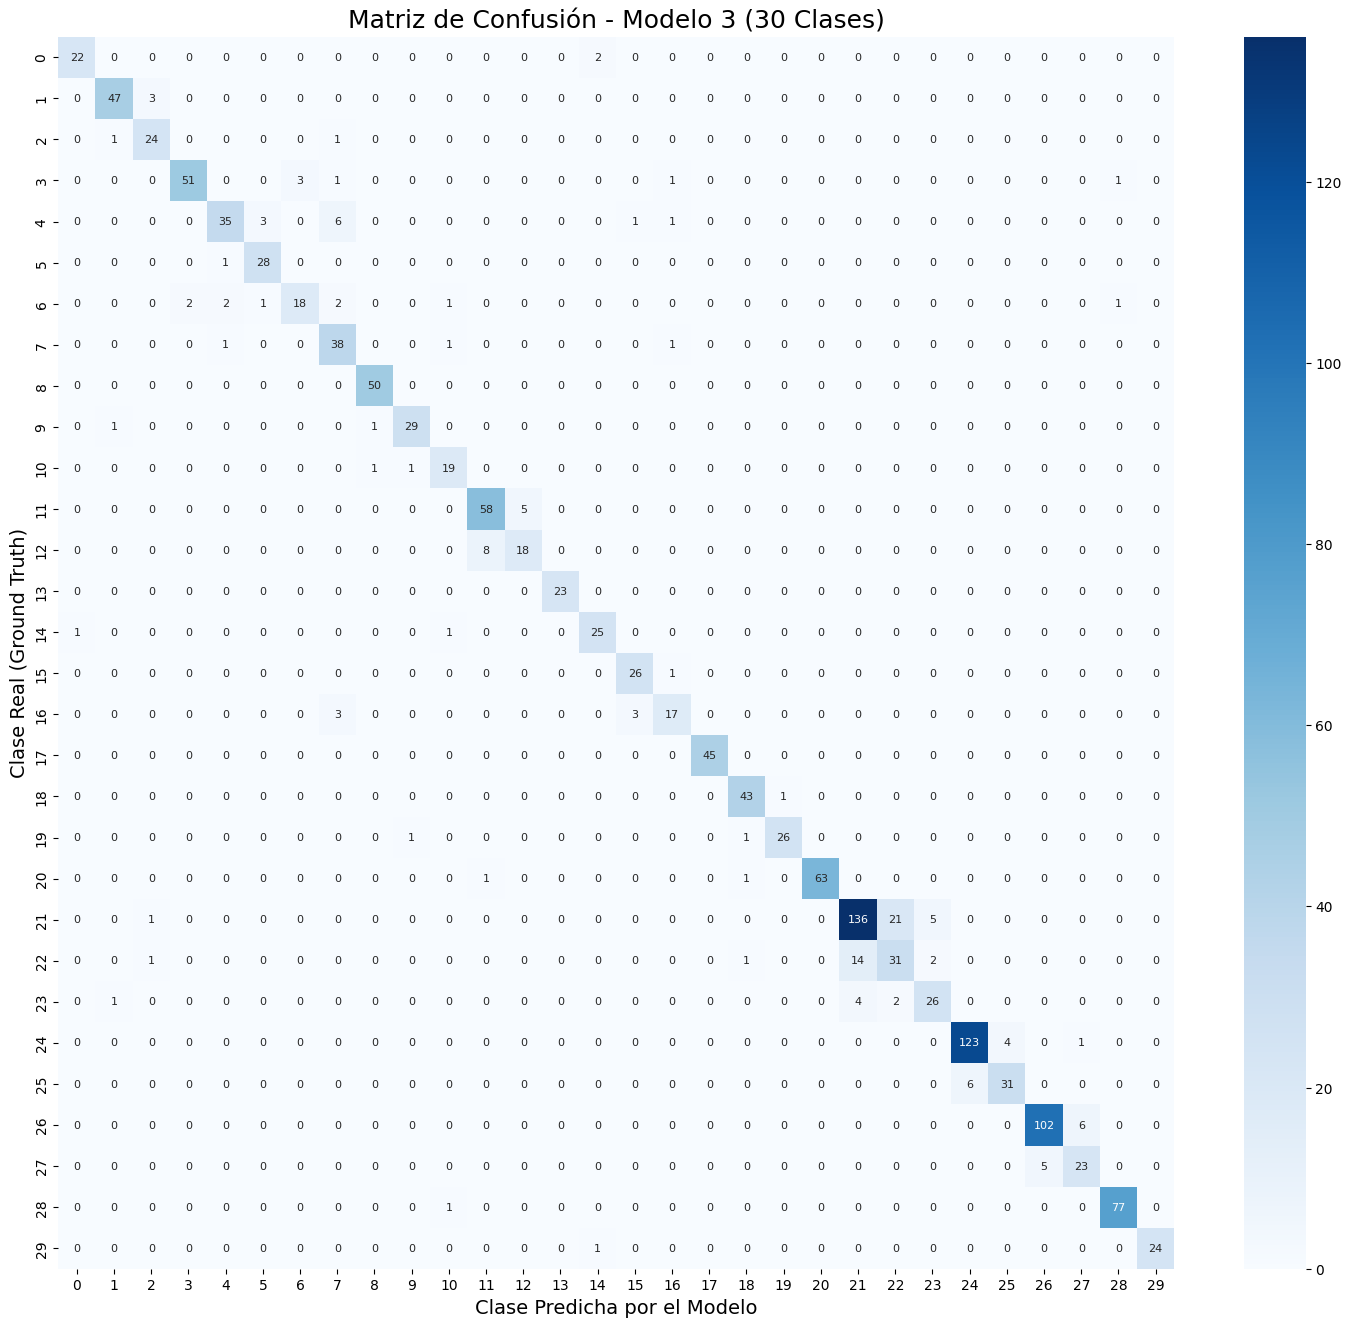

In [ ]:
# =========================================
# GRÁFICOS DE DESEMPEÑO Y MATRIZ DE CONFUSIÓN
# =========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Gráficos de Loss y Accuracy (Usando el history_3 del Modelo 3)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Loss
axes[0].plot(history_3.history['loss'], label='Pérdida (Loss) Entrenam.', color='#ff5252', linewidth=2)
axes[0].set_title('Evolución de la Función de Pérdida (Loss)', fontsize=14)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Sparse Categorical Crossentropy', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()

# Gráfico de Accuracy
axes[1].plot(history_3.history['accuracy'], label='Precisión (Accuracy) Entrenam.', color='#448aff', linewidth=2)
axes[1].set_title('Evolución del Accuracy', fontsize=14)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

# 2. Matriz de Confusión (Modelo 3) con números
plt.figure(figsize=(18, 16)) # Agrandamos un poco el lienzo para que respiren los números
cm = confusion_matrix(y_test_enc, y_pred_3)

# annot=True: enciende los números
# fmt='d': asegura que los números se muestren como enteros y no en notación científica
# annot_kws={"size": 8}: achica un poco la fuente de los números para que quepan en las celdas
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, annot_kws={"size": 8})

plt.title('Matriz de Confusión - Modelo 3 (30 Clases)', fontsize=18)
plt.xlabel('Clase Predicha por el Modelo', fontsize=14)
plt.ylabel('Clase Real (Ground Truth)', fontsize=14)
plt.show()

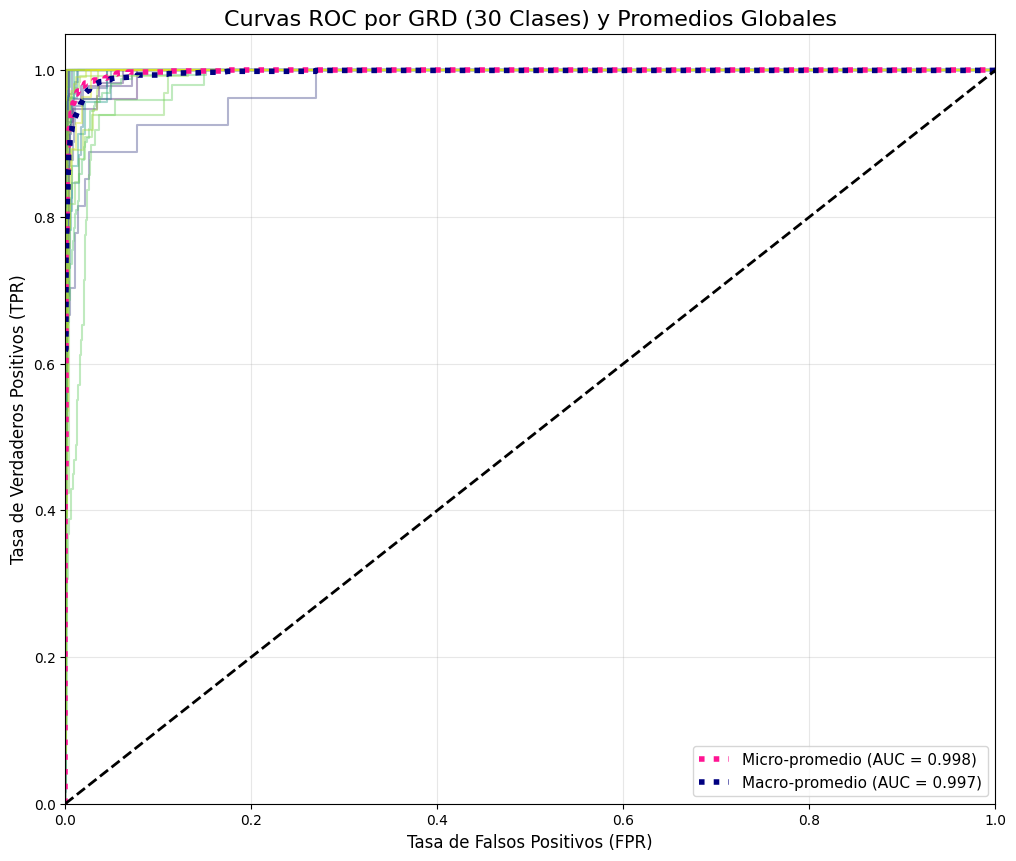

In [ ]:
# =========================================
# GRÁFICO DE CURVA ROC (LAS 30 CLASES + PROMEDIOS)
# =========================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# 1. Binarizar las etiquetas (One-vs-Rest)
y_test_bin = label_binarize(y_test_enc, classes=range(num_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

# 2. Calcular ROC y AUC para CADA UNA de las 30 clases
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob_3[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 3. Calcular promedios Micro y Macro

# Micro
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_prob_3.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# 4. Configurar el gráfico
plt.figure(figsize=(12, 10))

# Graficar las 30 clases (finas y semitransparentes usando un mapa de colores)
colores = plt.cm.viridis(np.linspace(0, 1, num_classes))
for i, color in zip(range(num_classes), colores):
    plt.plot(fpr[i], tpr[i], color=color, lw=1.5, alpha=0.4)

# Graficar los promedios encima (gruesos)
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-promedio (AUC = {roc_auc["micro"]:.3f})',
         color='deeppink', linestyle=':', linewidth=4)

plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-promedio (AUC = {roc_auc["macro"]:.3f})',
         color='navy', linestyle=':', linewidth=4)

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Línea de azar
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curvas ROC por GRD (30 Clases) y Promedios Globales', fontsize=16)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

Entrenando el modelo definitivo (Var 5)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
¡Entrenamiento finalizado! Generando gráficos...



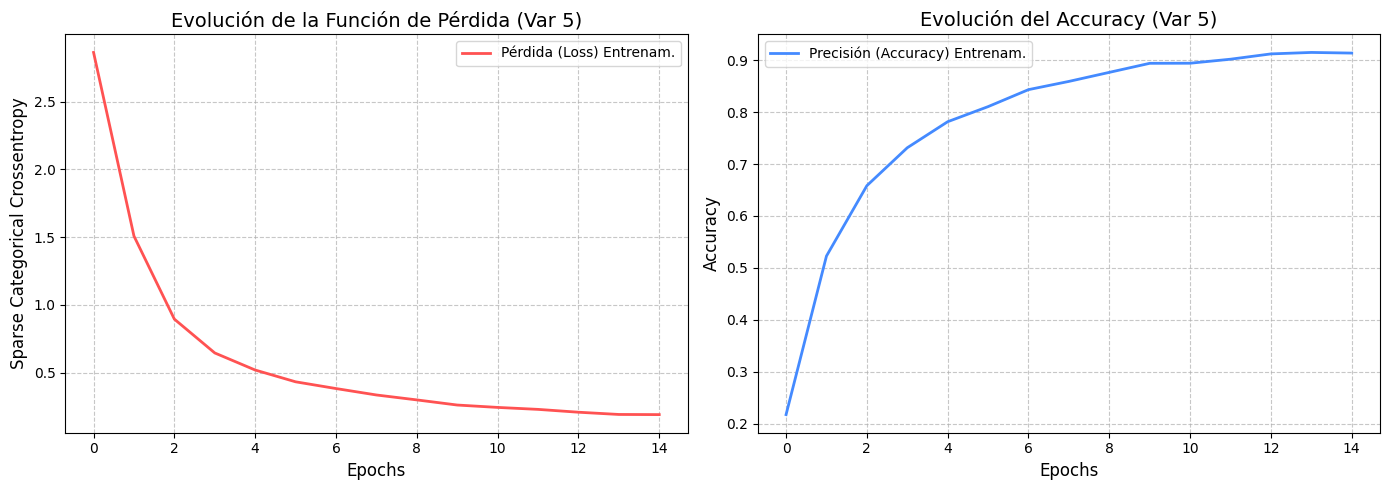

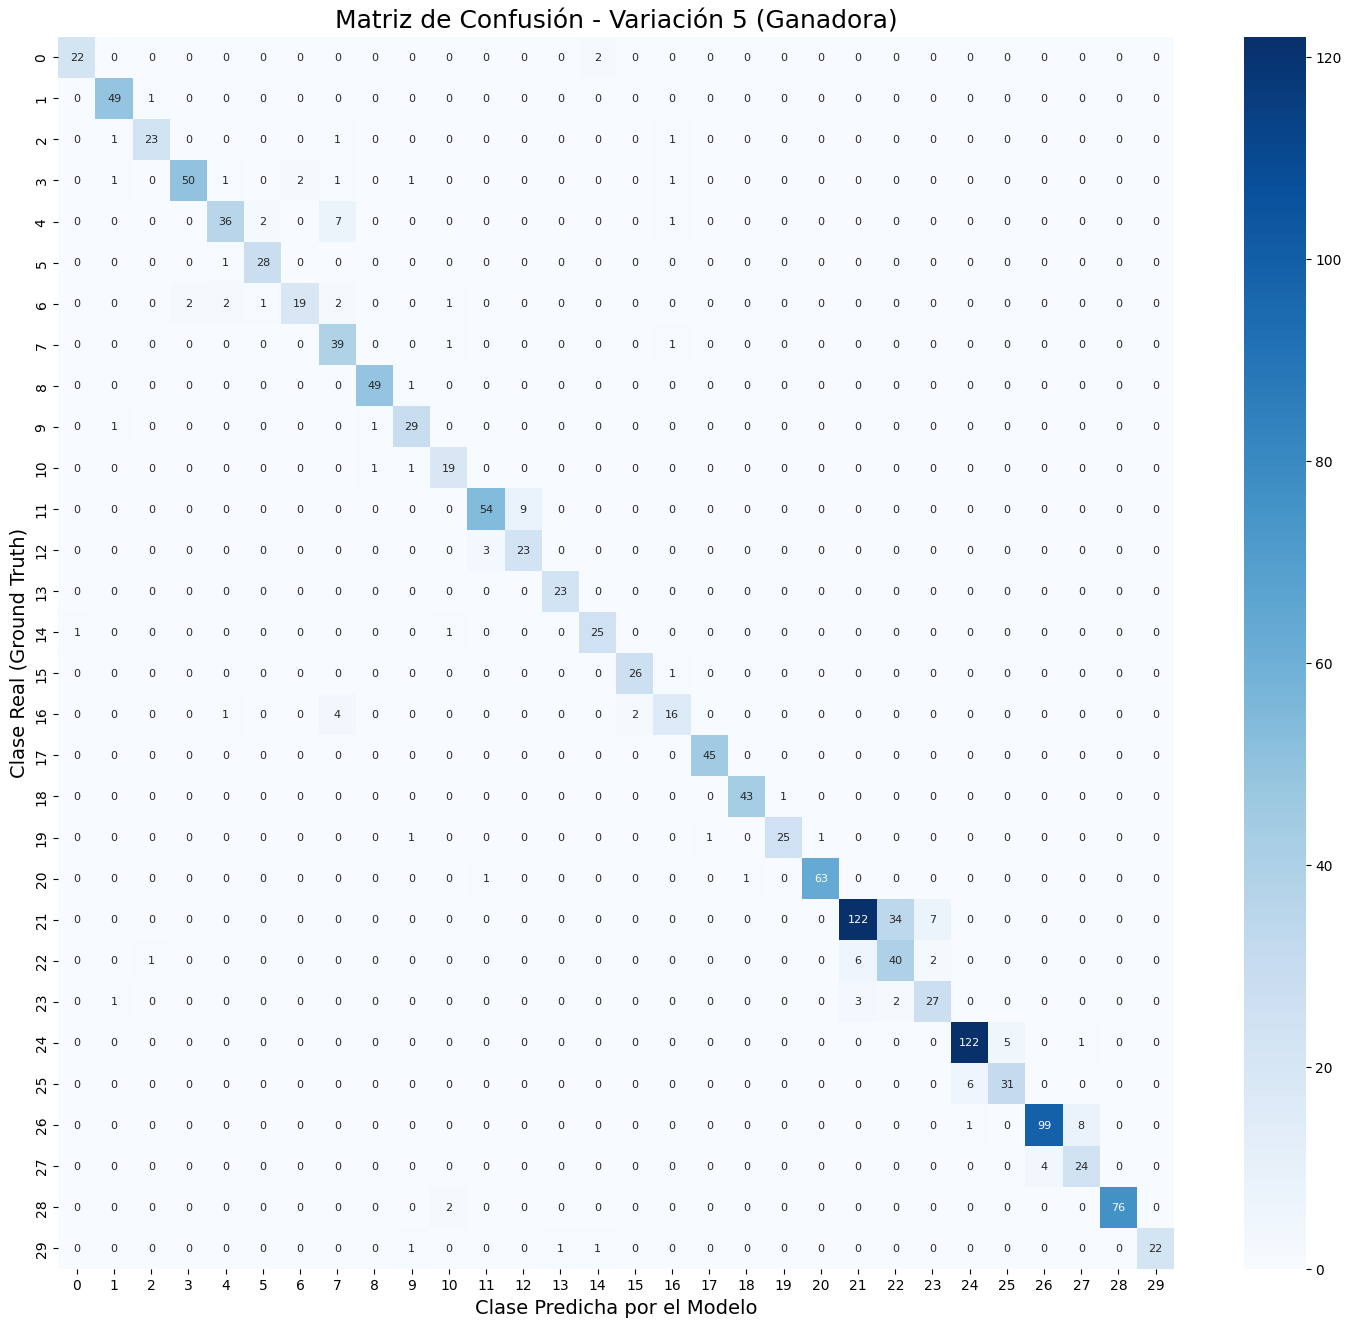

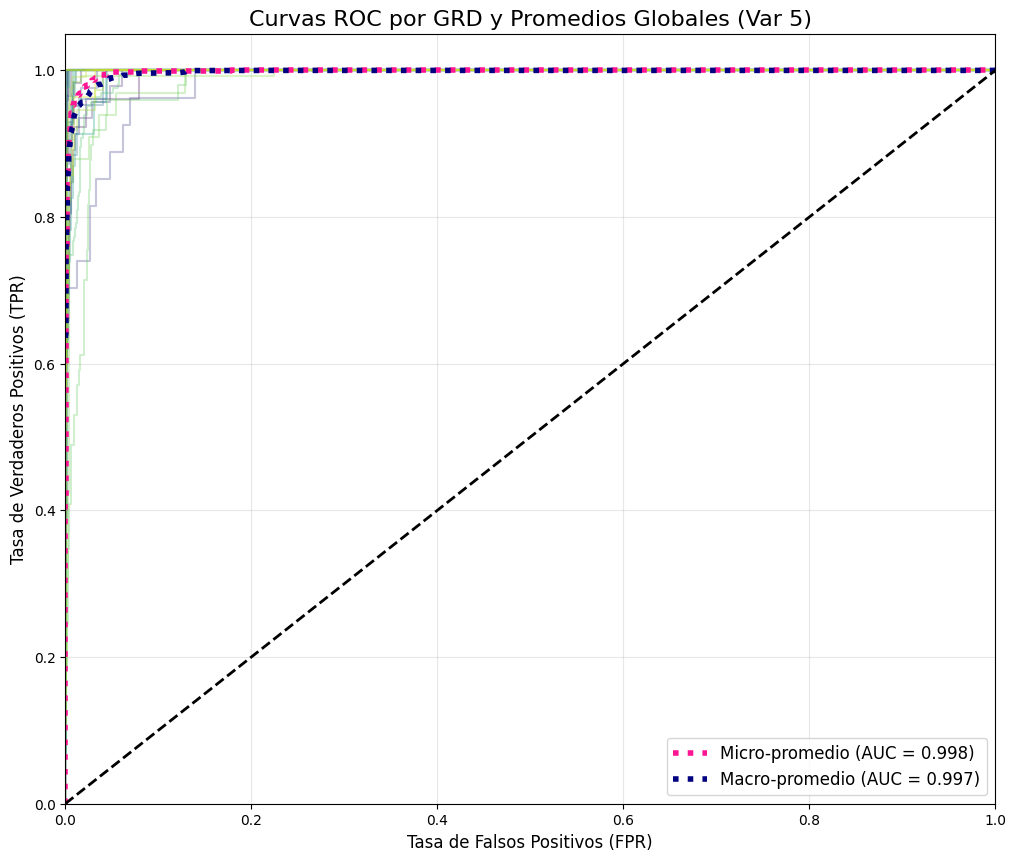

In [ ]:
# =========================================================
# ENTRENAMIENTO Y GRÁFICOS DEL MODELO GANADOR (VAR 5)
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

print("Entrenando el modelo definitivo (Var 5)...")

# 1. Arquitectura de Var 5: Capas [256, 128], Dropout 0.4, LR 0.001
model_ganador = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

model_ganador.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenar por 15 épocas para ver bien la curva de aprendizaje
history_ganador = model_ganador.fit(
    X_train.toarray(), y_train_enc,
    epochs=15, batch_size=32,
    class_weight=class_weights, verbose=0
)

# Predicciones
y_pred_prob_ganador = model_ganador.predict(X_test.toarray())
y_pred_ganador = np.argmax(y_pred_prob_ganador, axis=1)

print("¡Entrenamiento finalizado! Generando gráficos...\n")

# =========================================================
# GRÁFICO 1 Y 2: LOSS Y ACCURACY VS EPOCHS
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de Loss
axes[0].plot(history_ganador.history['loss'], label='Pérdida (Loss) Entrenam.', color='#ff5252', linewidth=2)
axes[0].set_title('Evolución de la Función de Pérdida (Var 5)', fontsize=14)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Sparse Categorical Crossentropy', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()

# Curva de Accuracy
axes[1].plot(history_ganador.history['accuracy'], label='Precisión (Accuracy) Entrenam.', color='#448aff', linewidth=2)
axes[1].set_title('Evolución del Accuracy (Var 5)', fontsize=14)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

# =========================================================
# GRÁFICO 3: MATRIZ DE CONFUSIÓN
# =========================================================
plt.figure(figsize=(18, 16))
cm_ganador = confusion_matrix(y_test_enc, y_pred_ganador)

sns.heatmap(cm_ganador, annot=True, fmt='d', cmap='Blues', cbar=True, annot_kws={"size": 8})
plt.title('Matriz de Confusión - Variación 5 (Ganadora)', fontsize=18)
plt.xlabel('Clase Predicha por el Modelo', fontsize=14)
plt.ylabel('Clase Real (Ground Truth)', fontsize=14)
plt.show()

# =========================================================
# GRÁFICO 4: CURVA ROC MULTICLASE (PROMEDIOS Y 30 CLASES)
# =========================================================
y_test_bin = label_binarize(y_test_enc, classes=range(num_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

# Calcular ROC y AUC para cada una de las 30 clases
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob_ganador[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Promedios Micro y Macro
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_prob_ganador.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Dibujar ROC
plt.figure(figsize=(12, 10))

# Líneas de las 30 clases (semitransparentes)
colores = plt.cm.viridis(np.linspace(0, 1, num_classes))
for i, color in zip(range(num_classes), colores):
    plt.plot(fpr[i], tpr[i], color=color, lw=1.5, alpha=0.3)

# Líneas de promedios (gruesas y punteadas)
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-promedio (AUC = {roc_auc["micro"]:.3f})',
         color='deeppink', linestyle=':', linewidth=4)

plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-promedio (AUC = {roc_auc["macro"]:.3f})',
         color='navy', linestyle=':', linewidth=4)

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curvas ROC por GRD y Promedios Globales (Var 5)', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

# Análisis Exploratorio de los datos

--- ANÁLISIS DE COMPLETITUD ---

Top 15 columnas con más datos faltantes:
                         Columna  Porcentaje_Faltante
0   Diag 35 Secundario (cod+des)            99.807706
1   Diag 34 Secundario (cod+des)            99.725294
2   Diag 33 Secundario (cod+des)            99.704691
3   Diag 32 Secundario (cod+des)            99.608543
4   Diag 31 Secundario (cod+des)            99.539867
..                           ...                  ...
10  Diag 25 Secundario (cod+des)            98.667674
11  Diag 24 Secundario (cod+des)            98.523453
12  Diag 23 Secundario (cod+des)            98.262482
13  Diag 22 Secundario (cod+des)            97.912231
14  Diag 21 Secundario (cod+des)            97.575716

[15 rows x 2 columns]


/tmp/ipykernel_3667/2529872798.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=missing_df, x='Porcentaje_Faltante', y='Columna', palette='viridis')


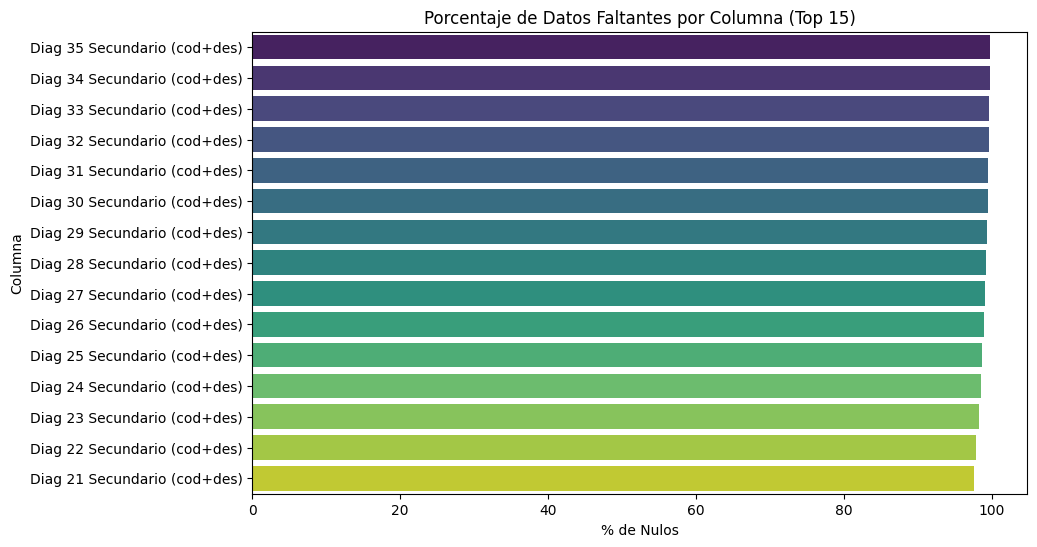


Resumen de nulos por fila:
count    14561.000000
mean        44.608543
std         11.404394
min          0.000000
25%         40.000000
50%         47.000000
75%         53.000000
max         63.000000
Name: nulos_por_fila, dtype: float64


In [ ]:
# Carga inicial
df = pd.read_csv('dataset_elpino.csv', sep=';', na_values='-', low_memory=False)

# --- COMPLETITUD ---
print("--- ANÁLISIS DE COMPLETITUD ---")
# 1. Porcentaje de valores nulos por columna (Top 15 con más faltantes)
missing_pct = df.isnull().mean() * 100
missing_df = missing_pct.sort_values(ascending=False).head(15).reset_index()
missing_df.columns = ['Columna', 'Porcentaje_Faltante']

print("\nTop 15 columnas con más datos faltantes:")
print(missing_df)

# Visualización de nulos por columna
plt.figure(figsize=(10, 6))
sns.barplot(data=missing_df, x='Porcentaje_Faltante', y='Columna', palette='viridis')
plt.title('Porcentaje de Datos Faltantes por Columna (Top 15)')
plt.xlabel('% de Nulos')
plt.show()

# 2. Análisis de registros (Filas)
df['nulos_por_fila'] = df.isnull().sum(axis=1)
print(f"\nResumen de nulos por fila:\n{df['nulos_por_fila'].describe()}")

In [ ]:
# --- CORRECTITUD ---
print("\n--- ANÁLISIS DE CORRECTITUD ---")

# 1. Conversión y validación de tipos
df['Edad'] = pd.to_numeric(df['Edad en años'], errors='coerce')
print(f"Valores de Edad no numéricos detectados: {df['Edad'].isnull().sum()}")

# 2. Consistencia de variables categóricas
print("\nDistribución por Sexo:")
print(df['Sexo (Desc)'].value_counts(dropna=False))

# 3. Creación de variables de complejidad clínica (Correctitud de registros)
diag_cols = [col for col in df.columns if col.startswith('Diag')]
proc_cols = [col for col in df.columns if col.startswith('Proced')]

df['num_diagnosticos'] = df[diag_cols].notnull().sum(axis=1)
df['num_procedimientos'] = df[proc_cols].notnull().sum(axis=1)

print("\nEstadísticas de Diagnósticos y Procedimientos por paciente:")
print(df[['num_diagnosticos', 'num_procedimientos']].describe())


--- ANÁLISIS DE CORRECTITUD ---
Valores de Edad no numéricos detectados: 0

Distribución por Sexo:
Sexo (Desc)
Mujer     9617
Hombre    4944
Name: count, dtype: int64

Estadísticas de Diagnósticos y Procedimientos por paciente:
       num_diagnosticos  num_procedimientos
count      14561.000000        14561.000000
mean           7.173958           13.217499
std            5.220577            7.362028
min            1.000000            1.000000
25%            3.000000            8.000000
50%            6.000000           11.000000
75%           10.000000           16.000000
max           35.000000           30.000000



--- ANÁLISIS DE OUTLIERS ---
Outliers detectados en Edad (sobre 115.50): 1
Outliers detectados en num_diagnosticos (sobre 20.50): 353
Outliers detectados en num_procedimientos (sobre 28.00): 1182


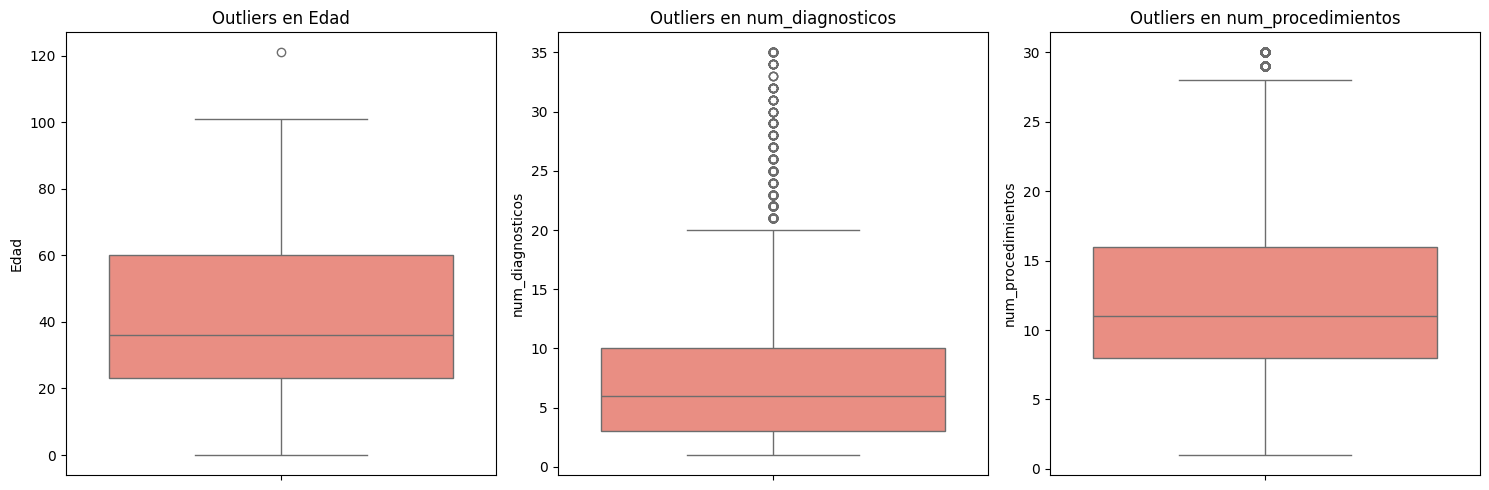

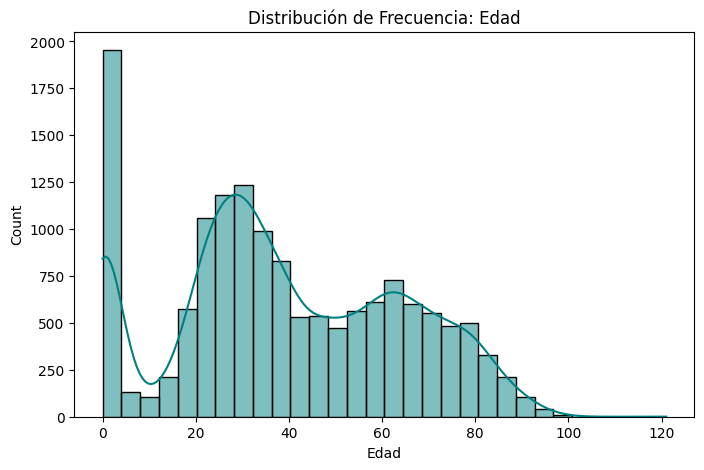

In [ ]:
# --- OUTLIERS ---
print("\n--- ANÁLISIS DE OUTLIERS ---")

variables_interes = ['Edad', 'num_diagnosticos', 'num_procedimientos']

plt.figure(figsize=(15, 5))

for i, var in enumerate(variables_interes):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[var], color='salmon')
    plt.title(f'Outliers en {var}')

    # Cálculo de límites usando IQR
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lim_sup = Q3 + 1.5 * IQR
    outliers_count = (df[var] > lim_sup).sum()
    print(f"Outliers detectados en {var} (sobre {lim_sup:.2f}): {outliers_count}")

plt.tight_layout()
plt.show()

# Histograma de Edad para ver la distribución de correctitud
plt.figure(figsize=(8, 5))
sns.histplot(df['Edad'].dropna(), bins=30, kde=True, color='teal')
plt.title('Distribución de Frecuencia: Edad')
plt.show()

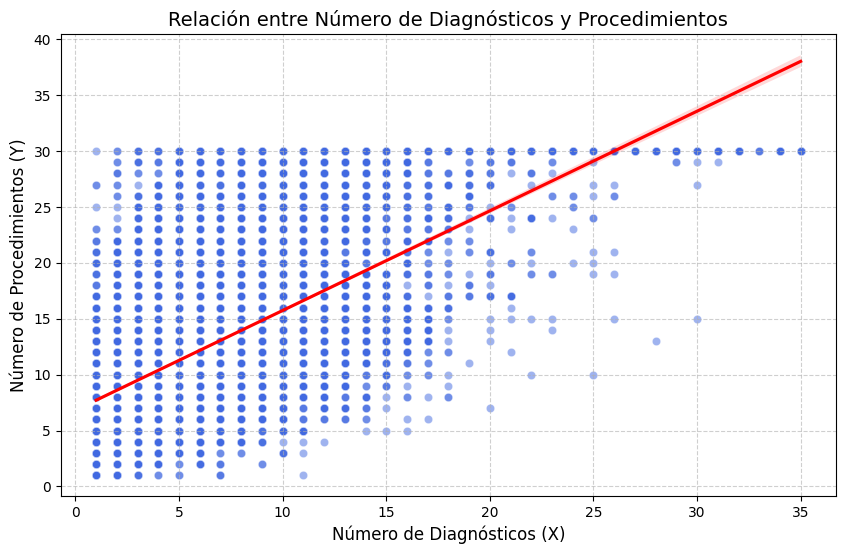

In [ ]:
# Crear el gráfico x vs y (Diagnósticos vs Procedimientos)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='num_diagnosticos', y='num_procedimientos', alpha=0.5, color='royalblue')

# Añadir una línea de tendencia para ver la relación
sns.regplot(data=df, x='num_diagnosticos', y='num_procedimientos', scatter=False, color='red')

plt.title('Relación entre Número de Diagnósticos y Procedimientos', fontsize=14)
plt.xlabel('Número de Diagnósticos (X)', fontsize=12)
plt.ylabel('Número de Procedimientos (Y)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

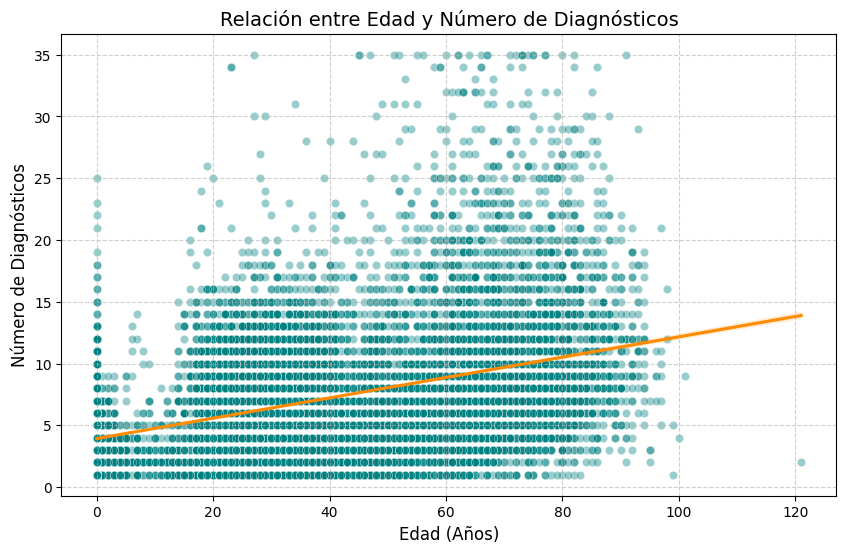

In [ ]:
# Crear el gráfico x vs y (Edad vs Diagnósticos)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Edad', y='num_diagnosticos', alpha=0.4, color='teal')

# Añadir una línea de tendencia (regresión)
sns.regplot(data=df, x='Edad', y='num_diagnosticos', scatter=False, color='darkorange')

plt.title('Relación entre Edad y Número de Diagnósticos', fontsize=14)
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Número de Diagnósticos', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

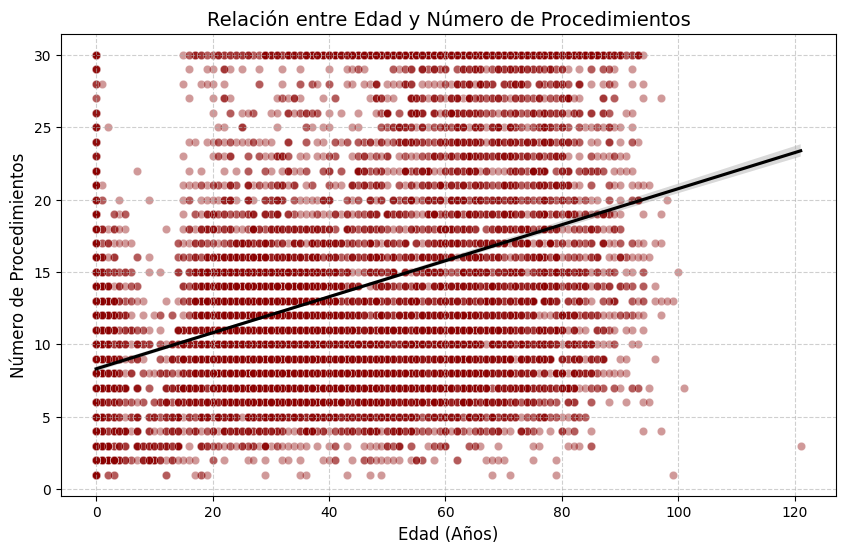

In [ ]:
# Crear el gráfico x vs y (Edad vs Procedimientos)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Edad', y='num_procedimientos', alpha=0.4, color='darkred')

# Añadir una línea de tendencia (regresión)
sns.regplot(data=df, x='Edad', y='num_procedimientos', scatter=False, color='black')

plt.title('Relación entre Edad y Número de Procedimientos', fontsize=14)
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Número de Procedimientos', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()